In [2]:
import pandas as pd
from pathlib import Path

BASE_DIR = Path.cwd().parent
PROCESSED_DIR = BASE_DIR / "data" / "processed"

df_fact_ticket = pd.read_csv(PROCESSED_DIR / "fact_ticket.csv")

df_fact_ticket["dob"] = pd.to_datetime(df_fact_ticket["dob"], errors="coerce")
df_fact_ticket["time"] = pd.to_datetime(df_fact_ticket["time"], errors="coerce")

In [4]:
df_fact_ticket.head(5)

,ticket_id,customer_id,paying_method,theater_name,device_number,original_price,discount_value,final_price,time,status_id,campaign_id,movie_name,usergender,dob,campaign_type,description,error_group,model,platform
0,4f5200dcdcf2396b8d50ff84bf423f32,100009,money in app,13.0,244764a57dbdeb8fe9b164847ad55183,9.90,2.10,7.80,2022-07-08 17:46:36.145,1,83330,Thor: Love And Thunder,Male,1989-02-25,direct discount,Order successful,no_error,"iPhone13,1",mobile
1,07abbaf28c772692f0367ad992bb3184,100493,bank account,180.0,8fa83cf46284aafd6e5da6c96f7862b5,8.66,1.48,7.18,2022-07-15 20:44:09.952,1,83330,Thor: Love And Thunder,Male,1991-06-09,direct discount,Order successful,no_error,browser,website
2,1fdbeb7eceba8a27d9d985b5b70c219a,100596,money in app,56.0,69cf9244654949047f006e441fa7a8a7,10.31,2.31,8.00,2022-07-30 11:16:55.483,1,0,Thor: Love And Thunder,Male,1989-05-18,no_campaign,Order successful,no_error,unknown,mobile
3,7715c9955866bd296b98543412839abd,100852,bank account,119.0,879ed11af9d6d2b5cda4d299590735a7,27.75,1.03,26.72,2022-07-04 22:33:07.458,1,85940,Thor: Love And Thunder,Male,1997-08-31,direct discount,Order successful,no_error,devicemodel,mobile
4,776efd7bda0b715084430e6385f67746,100965,money in app,107.0,0a233600d993a02cc1d39fb0d87fc7de,4.33,1.03,3.30,2022-07-03 18:41:45.098,1,85940,Thor: Love And Thunder,Male,1988-09-20,direct discount,Order successful,no_error,devicemodel,mobile


## Platform

In [6]:
df_platform_analysis = df_fact_ticket[[
    "platform",
    "final_price",
    "time"
]].copy()

In [10]:
df_platform_analysis["hour"] = df_platform_analysis["time"].dt.hour
df_platform_analysis["day_of_week"] = df_platform_analysis["time"].dt.day_name()
df_platform_analysis["month"] = df_platform_analysis["time"].dt.month

In [11]:
df_platform_analysis.head()

,platform,final_price,time,hour,day_of_week,month
0,mobile,7.80,2022-07-08 17:46:36.145,17,Friday,7
1,website,7.18,2022-07-15 20:44:09.952,20,Friday,7
2,mobile,8.00,2022-07-30 11:16:55.483,11,Saturday,7
3,mobile,26.72,2022-07-04 22:33:07.458,22,Monday,7
4,mobile,3.30,2022-07-03 18:41:45.098,18,Sunday,7


In [12]:
df_platform_analysis["platform"].value_counts()

platform
mobile     138134
website     16511
unknown        78
Name: count, dtype: int64

In [13]:
df_platform_analysis.groupby("platform")["final_price"].sum()

platform
mobile     1076424.67
unknown        592.37
website     123028.53
Name: final_price, dtype: float64

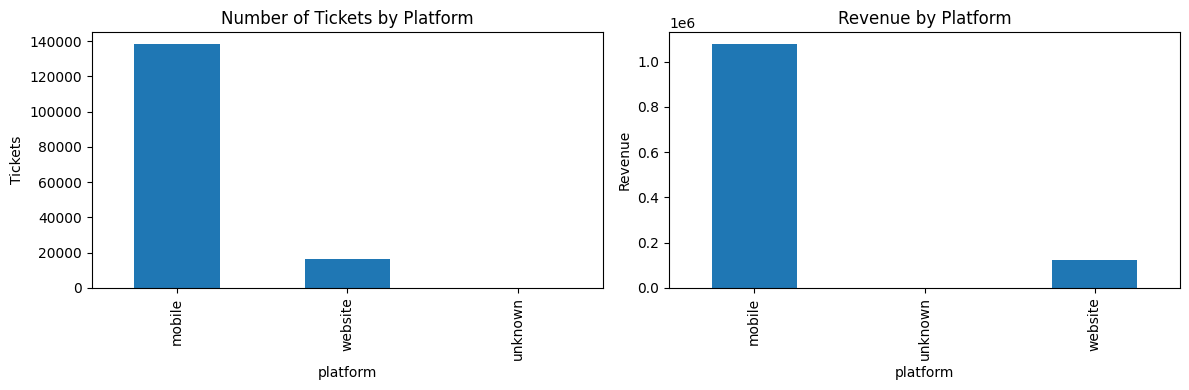

In [15]:
import matplotlib.pyplot as plt

# Data
ticket_counts = df_platform_analysis["platform"].value_counts()
revenue = df_platform_analysis.groupby("platform")["final_price"].sum()

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Chart 1: Ticket count
ticket_counts.plot(kind="bar", ax=axes[0])
axes[0].set_title("Number of Tickets by Platform")
axes[0].set_ylabel("Tickets")

# Chart 2: Revenue
revenue.plot(kind="bar", ax=axes[1])
axes[1].set_title("Revenue by Platform")
axes[1].set_ylabel("Revenue")

plt.tight_layout()
plt.show()

Mobile should be the primary focus for product development and optimization.
Marketing strategies should heavily prioritize mobile users to maximize conversion.
Website may require repositioning or redesign if the goal is to increase its contribution.

In [17]:
df_platform_clean = df_platform_analysis[
    df_platform_analysis["platform"] != "unknown"
].copy()

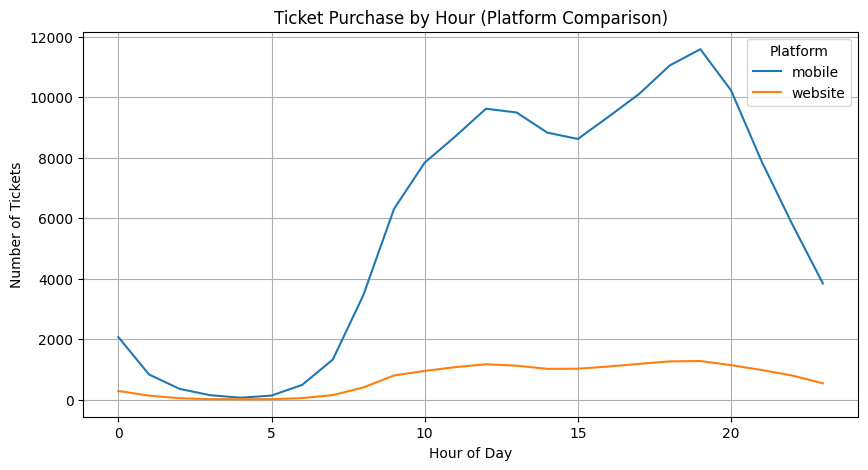

In [18]:
df_platform_clean.groupby(["hour", "platform"]).size().unstack().plot(figsize=(10,5))

plt.title("Ticket Purchase by Hour (Platform Comparison)")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Tickets")
plt.legend(title="Platform")
plt.grid(True)

plt.show()

Marketing timing should be consistent across platforms, focusing on peak evening hours
Mobile remains the priority channel for optimization and scaling
Website does not require separate time-based strategies, as user behavior is aligned with mobile

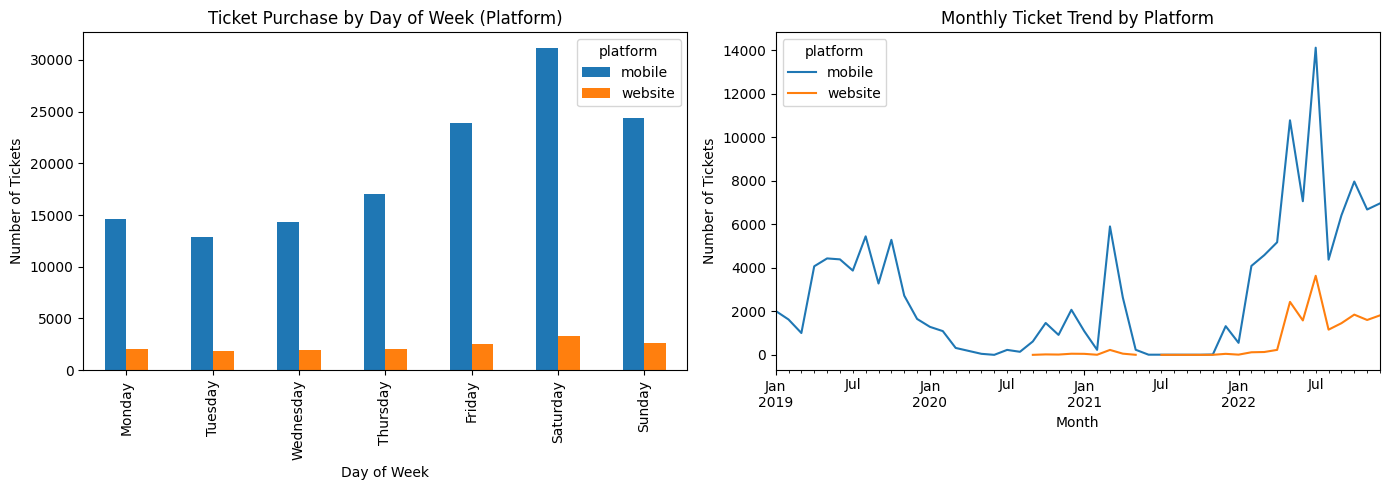

In [20]:
# Loại bỏ unknown
df_platform_clean = df_platform_analysis[
    df_platform_analysis["platform"] != "unknown"
].copy()

# Tạo year_month
df_platform_clean["year_month"] = df_platform_clean["time"].dt.to_period("M")

# Order cho day
order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

# Tạo figure
fig, axes = plt.subplots(1, 2, figsize=(14,5))

# 🔹 Chart 1: Day of week
df_platform_clean.groupby(["day_of_week","platform"]).size()\
    .unstack().reindex(order)\
    .plot(kind="bar", ax=axes[0])

axes[0].set_title("Ticket Purchase by Day of Week (Platform)")
axes[0].set_xlabel("Day of Week")
axes[0].set_ylabel("Number of Tickets")

# 🔹 Chart 2: Monthly trend
df_platform_clean.groupby(["year_month","platform"]).size()\
    .unstack()\
    .plot(ax=axes[1])

axes[1].set_title("Monthly Ticket Trend by Platform")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Number of Tickets")

plt.tight_layout()
plt.show()

Marketing strategies can be unified across platforms, as user behavior does not significantly differ between mobile and website.
Weekend, particularly Saturday, should be prioritized for high-impact campaigns.
Mobile should remain the primary focus for product optimization and scaling.
Website may require differentiation strategies if the goal is to expand its role beyond a secondary channel.

## Device

In [21]:
df_device_analysis = df_fact_ticket[[
    "model",
    "final_price",
    "time"
]].copy()

In [22]:
df_device_analysis.head(5)

,model,final_price,time
0,"iPhone13,1",7.80,2022-07-08 17:46:36.145
1,browser,7.18,2022-07-15 20:44:09.952
2,unknown,8.00,2022-07-30 11:16:55.483
3,devicemodel,26.72,2022-07-04 22:33:07.458
4,devicemodel,3.30,2022-07-03 18:41:45.098


In [23]:
df_device_analysis['model'].value_counts()

model
devicemodel         61865
browser             13377
unknown              6987
iPhone11,6           6119
iPhone9,4            4172
                    ...  
iPad13,17               1
Vivo vivo v3            1
Samsung SM-J727S        1
Zuk Z1                  1
Samsung SM-N9750        1
Name: count, Length: 1215, dtype: int64

In [27]:
def get_device_type(x):
    x = str(x).lower()
    
    if "iphone" in x or "ipad" in x:
        return "iOS"
    elif "browser" in x:
        return "Web"
    elif "unknown" in x or "devicemodel" in x:
        return "Unknown"
    else:
        return "Android"

df_device_analysis["device_type"] = df_device_analysis["model"].apply(get_device_type)

In [29]:
df_device_analysis["device_type"].value_counts()
df_device_analysis.groupby("device_type")["final_price"].sum()

device_type
Android    147468.33
Unknown    541505.88
Web         98155.73
iOS        412915.63
Name: final_price, dtype: float64

In [32]:
df_device_analysis["hour"] = df_device_analysis["time"].dt.hour
df_device_analysis["day_of_week"] = df_device_analysis["time"].dt.day_name()

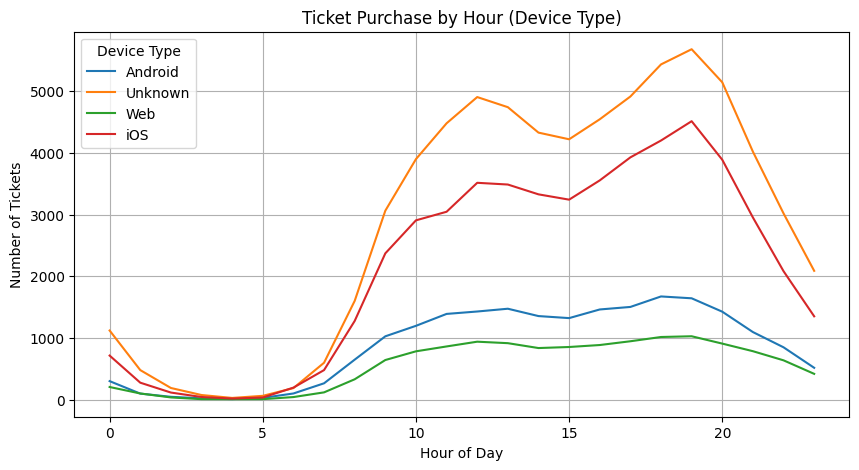

In [33]:
df_device_analysis.groupby(["hour", "device_type"]).size().unstack().plot(figsize=(10,5))

plt.title("Ticket Purchase by Hour (Device Type)")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Tickets")
plt.legend(title="Device Type")
plt.grid(True)

plt.show()

iOS users should be prioritized for premium offerings and targeted campaigns
Android users represent a mass segment and may benefit from broader promotional strategies
Mobile optimization should focus strongly on iOS performance and experience
Web channel plays a limited role and may require strategic repositioning

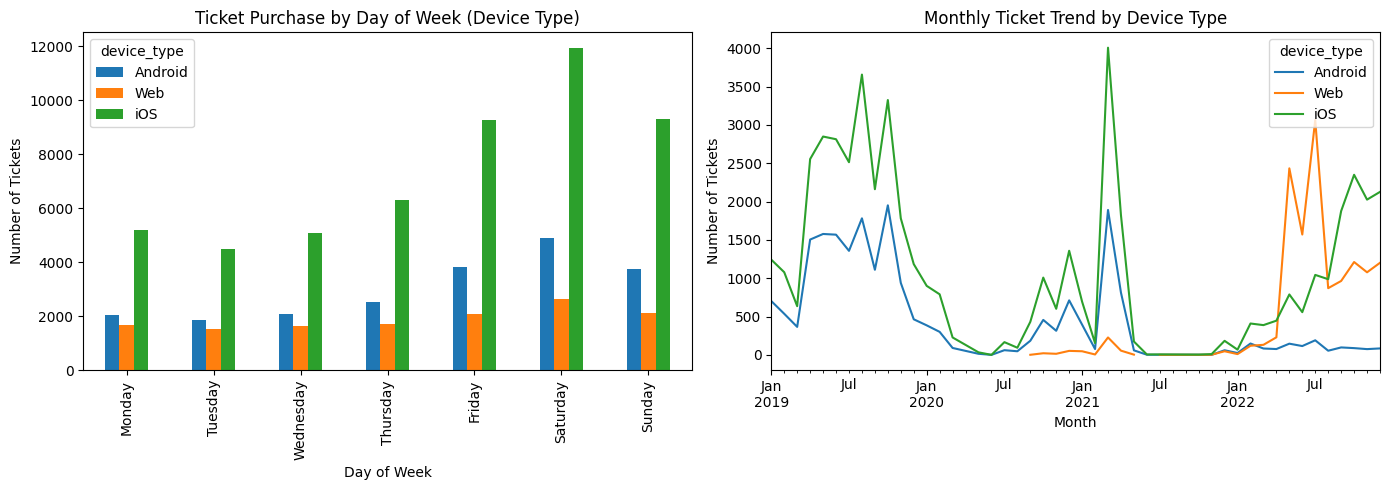

In [34]:
# 🔹 Clean data (bỏ unknown)
df_device_clean = df_device_analysis[
    df_device_analysis["device_type"] != "Unknown"
].copy()

# 🔹 Time features
df_device_clean["time"] = pd.to_datetime(df_device_clean["time"])
df_device_clean["day_of_week"] = df_device_clean["time"].dt.day_name()
df_device_clean["year_month"] = df_device_clean["time"].dt.to_period("M")

# 🔹 Order day
order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

# 🔹 Plot
fig, axes = plt.subplots(1, 2, figsize=(14,5))

# --- Chart 1: Day of week
df_device_clean.groupby(["day_of_week","device_type"]).size()\
    .unstack().reindex(order)\
    .plot(kind="bar", ax=axes[0])

axes[0].set_title("Ticket Purchase by Day of Week (Device Type)")
axes[0].set_xlabel("Day of Week")
axes[0].set_ylabel("Number of Tickets")

# --- Chart 2: Monthly trend
df_device_clean.groupby(["year_month","device_type"]).size()\
    .unstack()\
    .plot(ax=axes[1])

axes[1].set_title("Monthly Ticket Trend by Device Type")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Number of Tickets")

plt.tight_layout()
plt.show()

iOS users represent a high-value segment and should be prioritized for premium offerings and targeted campaigns
Android users represent a broader mass segment and may benefit from volume-driven strategies
Marketing timing can remain consistent across devices, as behavioral patterns are aligned
Growth strategies should leverage iOS users as high-engagement users during expansion phases

## Payment

In [2]:
df_payment_analysis = df_fact_ticket[[
    "paying_method",
    "final_price",
    "time"
]].copy()

In [19]:
df_payment_clean = df_payment_analysis[
    df_payment_analysis["payment_group"] != "other"
].copy()

In [21]:
df_payment_clean["payment_group"] = df_payment_clean["paying_method"].replace({
    "money in app": "In-app",
    "bank account": "Bank/Card",
    "credit card": "Bank/Card",
    "debit card": "Bank/Card"
})

In [23]:
df_payment_clean["payment_group"].value_counts()

payment_group
Bank/Card    88141
In-app       66580
Name: count, dtype: int64

In [24]:
df_payment_clean["hour"] = df_payment_clean["time"].dt.hour
df_payment_clean["day_of_week"] = df_payment_clean["time"].dt.day_name()
df_payment_clean["year_month"] = df_payment_clean["time"].dt.to_period("M")

In [25]:
df_payment_clean.head(5)

,paying_method,final_price,time,payment_group,hour,day_of_week,year_month
0,money in app,7.80,2022-07-08 17:46:36.145,In-app,17,Friday,2022-07
1,bank account,7.18,2022-07-15 20:44:09.952,Bank/Card,20,Friday,2022-07
2,money in app,8.00,2022-07-30 11:16:55.483,In-app,11,Saturday,2022-07
3,bank account,26.72,2022-07-04 22:33:07.458,Bank/Card,22,Monday,2022-07
4,money in app,3.30,2022-07-03 18:41:45.098,In-app,18,Sunday,2022-07


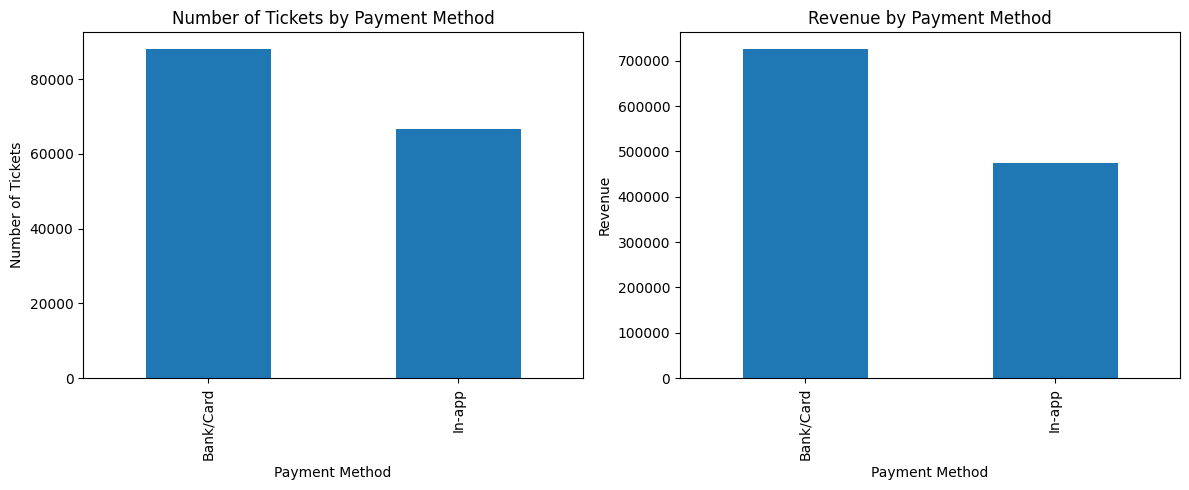

In [26]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12,5))

# --- Ticket count
df_payment_clean["payment_group"].value_counts().plot(
    kind="bar",
    ax=axes[0]
)

axes[0].set_title("Number of Tickets by Payment Method")
axes[0].set_xlabel("Payment Method")
axes[0].set_ylabel("Number of Tickets")

# --- Revenue
df_payment_clean.groupby("payment_group")["final_price"].sum().plot(
    kind="bar",
    ax=axes[1]
)

axes[1].set_title("Revenue by Payment Method")
axes[1].set_xlabel("Payment Method")
axes[1].set_ylabel("Revenue")

plt.tight_layout()
plt.show()

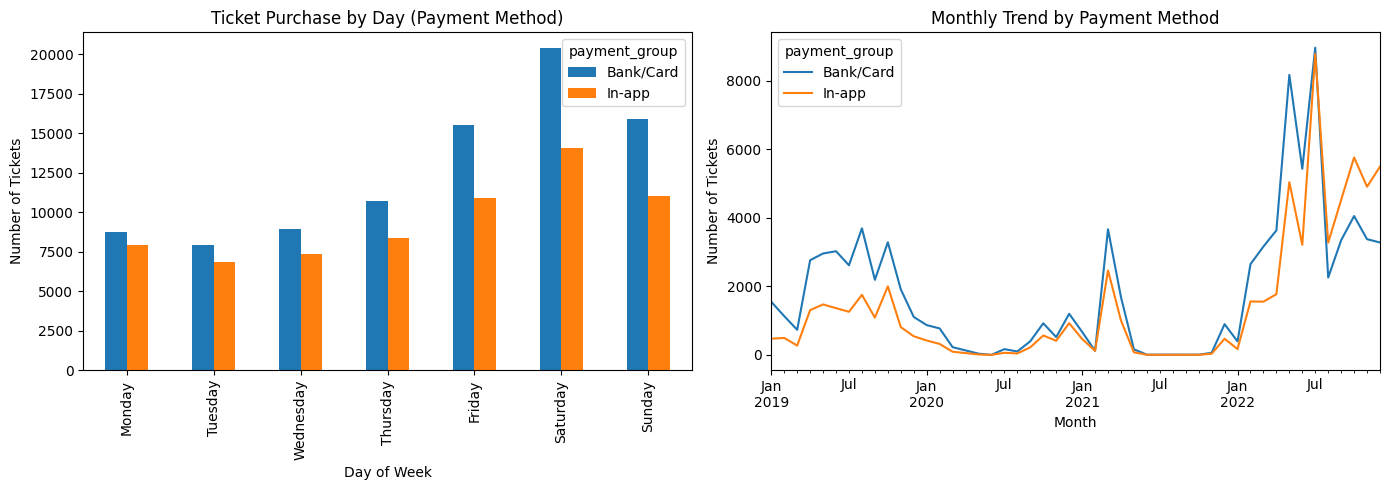

In [27]:
order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

fig, axes = plt.subplots(1, 2, figsize=(14,5))

# --- Day
df_payment_clean.groupby(["day_of_week","payment_group"]).size()\
    .unstack().reindex(order)\
    .plot(kind="bar", ax=axes[0])

axes[0].set_title("Ticket Purchase by Day (Payment Method)")
axes[0].set_xlabel("Day of Week")
axes[0].set_ylabel("Number of Tickets")

# --- Month
df_payment_clean.groupby(["year_month","payment_group"]).size()\
    .unstack()\
    .plot(ax=axes[1])

axes[1].set_title("Monthly Trend by Payment Method")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Number of Tickets")

plt.tight_layout()
plt.show()

🎯 English

Bank/Card is the dominant payment method across the platform, leading both transaction volume and revenue generation.

In-app payment contributes a substantial share of activity but remains secondary in both usage and revenue.

Behavioral analysis reveals that both payment methods follow nearly identical temporal patterns across days and months, with transaction activity peaking during weekends and increasing significantly during the platform’s recovery phase in 2022.

This suggests that payment method does not significantly influence user purchasing behavior over time, but rather reflects user preference in transaction execution.

💼 BUSINESS VALUE
Bank/Card should remain the primary focus for payment optimization and partnerships
In-app payment still represents a meaningful secondary channel and can be leveraged for loyalty programs or retention strategies
Marketing timing can remain unified across payment methods due to highly aligned behavioral patterns
Future growth opportunities may come from incentivizing In-app adoption rather than changing behavioral timing

## Promotion progams


In [28]:
df_campaign_analysis = df_fact_ticket[[
    "campaign_type",
    "final_price",
    "time"
]].copy()

In [32]:
df_campaign_analysis.head(5)

,campaign_type,final_price,time,hour,day_of_week,year_month
0,direct discount,7.80,2022-07-08 17:46:36.145,17,Friday,2022-07
1,direct discount,7.18,2022-07-15 20:44:09.952,20,Friday,2022-07
2,no_campaign,8.00,2022-07-30 11:16:55.483,11,Saturday,2022-07
3,direct discount,26.72,2022-07-04 22:33:07.458,22,Monday,2022-07
4,direct discount,3.30,2022-07-03 18:41:45.098,18,Sunday,2022-07


In [31]:
df_campaign_analysis["hour"] = df_campaign_analysis["time"].dt.hour
df_campaign_analysis["day_of_week"] = df_campaign_analysis["time"].dt.day_name()
df_campaign_analysis["year_month"] = df_campaign_analysis["time"].dt.to_period("M")

In [30]:
df_campaign_analysis["campaign_type"].value_counts()

campaign_type
direct discount    79828
no_campaign        63097
voucher             7619
reward point        4179
Name: count, dtype: int64

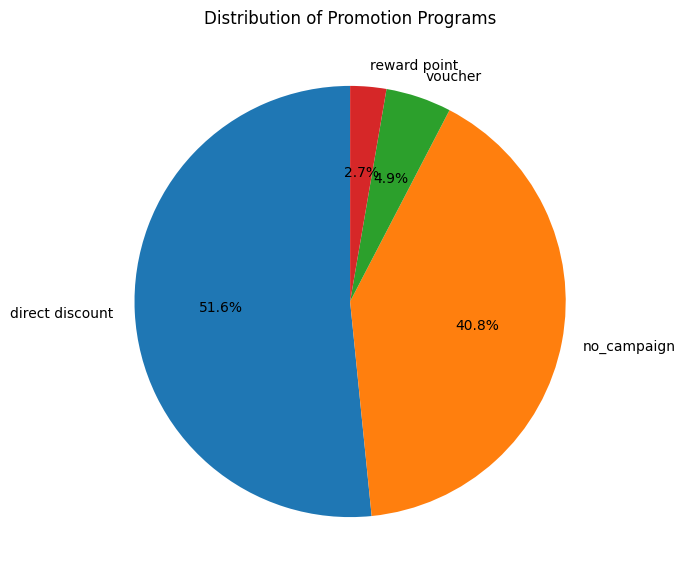

In [33]:
import matplotlib.pyplot as plt

campaign_counts = df_campaign_analysis["campaign_type"].value_counts()

# Pie chart
plt.figure(figsize=(7,7))

campaign_counts.plot(
    kind="pie",
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Distribution of Promotion Programs")
plt.ylabel("")  
plt.show()

Direct discount accounts for the largest share of promotional activity, highlighting its central role in driving transactions.

Meanwhile, a substantial proportion of purchases occur without promotions, indicating strong organic demand.

Voucher and reward-point programs contribute only a minor share, suggesting limited adoption of loyalty-based incentives.

Direct discounts are highly effective for driving transaction volume and short-term conversion
The platform possesses strong organic demand and does not rely entirely on promotional incentives
Voucher and reward-point systems may require redesign or stronger incentives to improve adoption and engagement
Future campaign strategies should balance short-term conversion tactics with long-term loyalty development

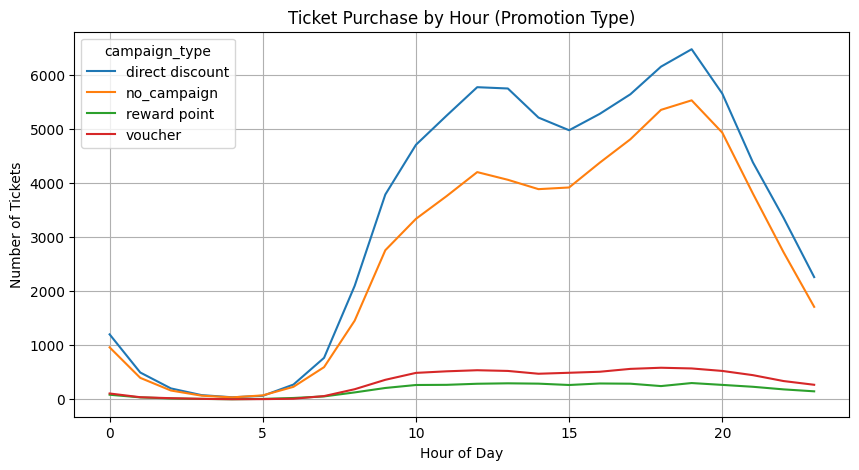

In [34]:
df_campaign_analysis.groupby(["hour","campaign_type"]).size().unstack().plot(
    figsize=(10,5)
)

plt.title("Ticket Purchase by Hour (Promotion Type)")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Tickets")

plt.grid(True)
plt.show()

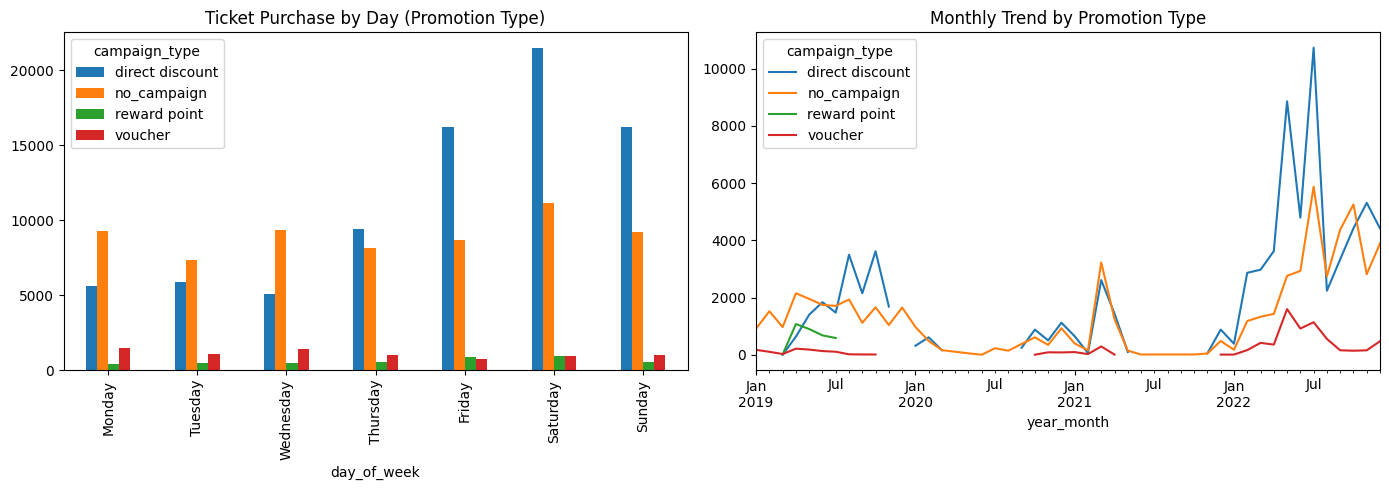

In [35]:
order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

fig, axes = plt.subplots(1, 2, figsize=(14,5))

# Day
df_campaign_analysis.groupby(["day_of_week","campaign_type"]).size()\
    .unstack().reindex(order)\
    .plot(kind="bar", ax=axes[0])

axes[0].set_title("Ticket Purchase by Day (Promotion Type)")

# Month
df_campaign_analysis.groupby(["year_month","campaign_type"]).size()\
    .unstack()\
    .plot(ax=axes[1])

axes[1].set_title("Monthly Trend by Promotion Type")

plt.tight_layout()
plt.show()

🎯 English

Promotional campaigns significantly influence transaction volume but do not fundamentally change purchasing behavior patterns.

Direct discount campaigns generate the highest activity, particularly during evening hours and weekends, indicating that users respond strongly to immediate price reductions during peak leisure periods.

However, the temporal patterns of direct discount transactions closely mirror those of non-promotional purchases, suggesting that promotions primarily reinforce existing demand rather than creating new purchasing behavior.

Voucher and reward-point programs contribute relatively little transaction volume and show limited impact on behavioral patterns, indicating weaker engagement with loyalty-based incentives.

Long-term trend analysis further reveals that both promotional and non-promotional transactions experienced similar declines and recovery cycles, implying that external market conditions and entertainment demand remain the dominant drivers of user activity.

💼 BUSINESS VALUE
Direct discount campaigns are highly effective for maximizing conversions during peak demand periods
Current promotions are more successful at amplifying existing demand than generating off-peak activity
Voucher and reward-point systems may require redesign or stronger incentives to improve effectiveness
Future promotional strategies should focus on stimulating low-demand periods rather than concentrating solely on peak hours
Organic demand remains strong, reducing overreliance on promotional spending

## What types of movies do customer books ?


In [3]:
df_movie_analysis = df_fact_ticket[[
    "movie_name",
    "final_price",
    "time"
]].copy()

In [4]:
df_movie_analysis["hour"] = df_movie_analysis["time"].dt.hour
df_movie_analysis["day_of_week"] = df_movie_analysis["time"].dt.day_name()
df_movie_analysis["year_month"] = df_movie_analysis["time"].dt.to_period("M")

In [7]:
df_movie_analysis["movie_name"].value_counts().head(10)


movie_name
Doctor Strange In The Multiverse Of Madness    10043
Minions: The Rise Of Gru                        8207
Avatar: The Way Of Water                        6351
Thor: Love And Thunder                          6346
Peninsula                                       6036
Black Panther 2: Wakanda Forever                4222
Avengers: Endgame                               4052
Dad I'm Sorry                                   3571
Black Adam                                      3530
You And Trinh                                   2725
Name: count, dtype: int64

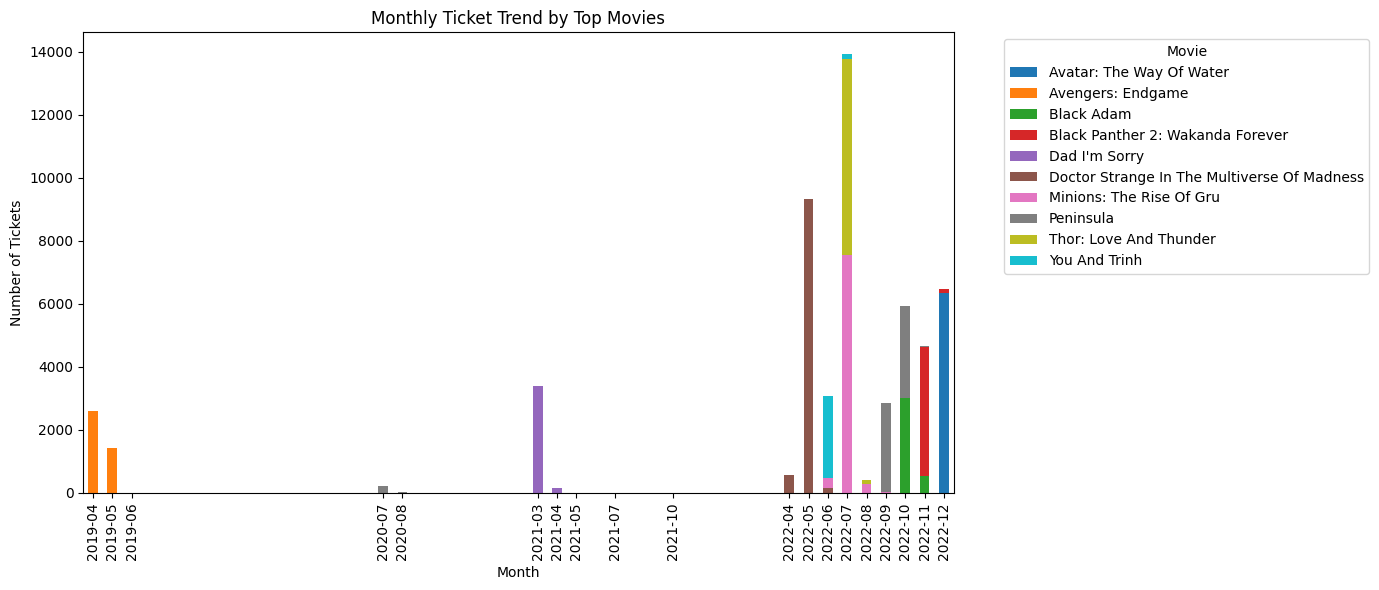

In [11]:
import matplotlib.pyplot as plt

# Top 10 movies by ticket count
top_movies = df_movie_analysis["movie_name"].value_counts().head(10).index

df_top_movies = df_movie_analysis[
    df_movie_analysis["movie_name"].isin(top_movies)
].copy()

# Monthly movie trend
movie_month_trend = df_top_movies.groupby(
    ["year_month", "movie_name"]
).size().unstack(fill_value=0)

# Plot stacked bar
movie_month_trend.plot(
    kind="bar",
    stacked=True,
    figsize=(14, 6)
)

plt.title("Monthly Ticket Trend by Top Movies")
plt.xlabel("Month")
plt.ylabel("Number of Tickets")
plt.legend(title="Movie", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

🎯 English

Movie transaction trends reveal that platform demand is highly driven by blockbuster releases.

Individual movies generate distinct transaction spikes during their release periods, followed by rapid decline in activity, indicating short-lived but intense engagement cycles.

Major titles such as Doctor Strange in the Multiverse of Madness, Thor: Love and Thunder, and Avatar: The Way of Water contributed disproportionately to transaction growth during 2022.

This suggests that content attractiveness plays a critical role in driving user activity and overall platform performance.

Rather than steady organic growth across all titles, the platform exhibits strong dependence on high-profile movie releases to generate transaction surges.

💼 BUSINESS VALUE
Blockbuster releases should be treated as key revenue-driving events
Marketing campaigns should align closely with major movie launches
The platform may face volatility due to heavy dependence on a small number of high-performing titles
Sustaining engagement between blockbuster periods may require alternative content or loyalty strategies